# Project Setup

Pertama tama kita perlu menyiapkan beberapa library yang akan digunakan di precessing nanti. Disini saya melakukan import ke 4 library di python yaitu pandas, numpy, seaborn, dan matplotlib.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Setup and EDA

### **Membaca dataset dan menampilkan 5 baris teratas**

Selanjutnya yang saya lakukan yaitu membaca dataset menggunakan fungsi `pd.read_csv` yang mana nanti akan terbentuk variable `data` dengan tipe dataframe.

In [3]:
data = pd.read_csv("/content/drive/MyDrive/College/Data Mining/Tugas EDA Praktikkum 1/spotify_churn_dataset.csv")
display(data.head(5))
display(data.tail(5))
display(data.shape)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0
7999,8000,Other,45,AU,Free,210,68,0.46,Desktop,6,0,0


(8000, 12)

Disini saya juga menampilkan 5 baris teratas pada data tersebut menggunakan fungsi `.head()` dan menampilkan informasi dimensi data menggunakan fungsi `.shape()`. Berdasarkan outputnya, kita dapat mengetahui bahwa dataset kita ini berisi 8000 baris dan 12 kolom.

### **Menampilkan info dataset**

Selanjutnya yaitu menampilkan beberapa informasi data seperti tipe data pada setiap fitur, banyak nilai yang terisi (non-null), nama - nama fitur, dan lain lain menggunakan fungsi `.info()`

In [4]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


None

Dari outputnya kita dapat melihat bahwa ada beberapa fitur yang memiliki tipe numerik (int64, float64) seperti `user_id`, `age`, `listening_time`, `songs_played_per_day`, `skip_rate`, `ads_listened_per_week`, `offline_listening`, dan `is_churned`. Lalu selanjutnya fitur dengan tipe kategorikal (object) seperti `gender`, `country`, `subscription_type`, dan `device_type`.

### **Memisahkan antara fitur numerik dengan kategorikal**

Selanjutnya yaitu kita perlu memisahkan antara fitur numerik dengan kategorikal. Nah, bukannya tadi sudah di check fitur numerik dan kategorikal nya? ya, tapi itu belum cukup karena apabila kita check lagi di dataset tadi, ada fitur yang merupakan kategorikal tapi karena isinya angka bulat (ex: 1, 0) maka sebenarnya fitur itu bukan masuk ke numerik, lebih tepatnya di kategorikal. Disini kita bisa melakukan check fitur mana saja yang merupakan kategorikal berdasarkan banyak nilai unique per fiturnya menggunakan fungsi `.nunique()`.

In [5]:
display(data.nunique())

,0
user_id,8000
gender,3
age,44
country,8
subscription_type,4
listening_time,290
songs_played_per_day,99
skip_rate,61
device_type,3
ads_listened_per_week,46


Nah, terlihat disini kalau fitur yang sebelumnya termasuk ke numerik tapi isinya hanya 2 data saja yaitu `0` dan `1`. Fitur ini yaitu `offline_listening` dan `is_churned`. Nah, selanjutnya kita bisa mengelompokkan masing masing fiturnya ke kelompok yang sesuai supaya saat preprocessing selanjutnya bisa lebih mudah, hal ini dikarenakan beda tipe fitur maka beda juga cara preprocessnya.

In [6]:
num_features = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_features = ['gender', 'country', 'subscription_type', 'device_type', 'offline_listening', 'is_churned']

print("Numerik:", num_features)
print("Kategorikal:", cat_features)

Numerik: ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
Kategorikal: ['gender', 'country', 'subscription_type', 'device_type', 'offline_listening', 'is_churned']


### **Mengitung Deskripsi Statistik (ex: Mean, Median, Mode, Standar Deviasi)**

Selanjutnya kita menghitung beberapa deskripsi statistik seperti rata - rata, median, modus, dan standar deviasi pada fitur numerik saja. Nah, disini saya membuat 5 fungsi untuk menghitung masing - masing nilai yaitu rata - rata, median, modus, standard deviasi sampel, dan standar deviasi populasi.

In [7]:
cols = []
results = []

class StatDesc():
    def __init__(self, values) -> None:
        self.values = values

    def mean(self) -> float:
        return np.sum(self.values) / len(self.values)

    def mode(self) -> float:
        sorted_vals = np.sort(self.values)
        vals, counts = np.unique(sorted_vals, return_counts=True)
        return vals[np.argmax(counts)]

    def median(self) -> float:
        sorted_vals = np.sort(self.values)
        n = len(self.values)
        if n % 2 == 0:
            return (sorted_vals[n//2 - 1] + sorted_vals[n//2]) / 2
        else:
            return sorted_vals[n//2]

    def std_pop(self) -> float:
        variance = np.sum((self.values - self.mean()) ** 2) / len(self.values)
        return np.sqrt(variance)

    def std_sample(self) -> float:
        variance = np.sum((self.values - self.mean()) ** 2) / (len(self.values) - 1)
        return np.sqrt(variance)

for values in num_features:
    cols.append(values)

for values in num_features:
    vals = data[values].to_numpy()
    sd = StatDesc(vals)
    stats = {
        "": values,
        "mean":   (sd.mean()),
        "median": (sd.median()),
        "mode":   (sd.mode()),
        "std_pop":(sd.std_pop()),
        "std_sample":(sd.std_sample())
    }
    results.append(stats)

display(pd.DataFrame(results).set_index(""))

,mean,median,mode,std_pop,std_sample
,,,,,
age,37.662125,38.0,51.00,12.739563,12.740359
listening_time,154.068250,154.0,99.00,84.010345,84.015596
songs_played_per_day,50.127250,50.0,39.00,28.447984,28.449762
skip_rate,0.300127,0.3,0.34,0.173583,0.173594
ads_listened_per_week,6.943875,0.0,0.00,13.617102,13.617953


Oiya, jika tidak mau repot membuat fungsinya, kita juga bisa menggunakan fungsi `.describe()` yang sudah tersedia di python. Tapi untuk standar deviasi nya dia hanya menampilkan yang standar deviasi sampel saja. Berikut bisa dilihat deskripsi masing masing fiturnya.

In [20]:
display(data[num_features].describe())

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,37.662125,154.068250,50.127250,0.300127,6.943875
std,12.740359,84.015596,28.449762,0.173594,13.617953
min,16.000000,10.000000,1.000000,0.000000,0.000000
25%,26.000000,81.000000,25.000000,0.150000,0.000000
50%,38.000000,154.000000,50.000000,0.300000,0.000000
75%,49.000000,227.000000,75.000000,0.450000,5.000000
max,59.000000,299.000000,99.000000,0.600000,49.000000


### **Menhitung berapa banyak missing value per fitur**

Selanjutnya kita melakukan pengecekan ke missing value pada masing - masing kolom di dataset dengan menggunakan fungsi `.isnull()` untuk mendeteksi missing value dan menjumlahkan missing value yang terdeteksi menggunakan fungsi `.sum()`. Dan kabar baiknya pada dataset ini tidak terdapat missing value jadi tidak ada penanganan ke missing value nya. Tapi jika misalkan terdapat missing value, maka kita dapat menanganinya menggunakan beberapa strategi seperti melakukan drop pada baris atau kolom yang terdapat missing value atau mengisi missing value dengan nilai modus, median, rata - rata, dan lain lain.

In [9]:
data.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


### **Mengecek outlier pada setiap fitur**

Selanjutnya yaitu mengecek outlier pada setiap fitur numerik. Nah, kenapa fitur kategorikal tidak kita cek outlier nya? fitur kategorikal tidak di cek outlier nya dikarenakan fitur kategorikal isi nilainya hanya beberapa seperti hanya 8, 2, dan lain lain yang mana menjadikan isi dari fitur kategorikal ini tetap. Nah, sedangkan yang fitur numerik itu tidak ada batasan nilainya, jadi bisa saja ada beberapa nilai yang melenceng jauh dari mayoritas nilai di fitur tersebut. Hal ini lah yang perlukita perhatikan saat preprocessing. Disini saya memakai 4 teknik dalam pengecekan outlier yaitu ada boxplot, iqr, z-score, dan MAD.

**1. Menggunakan Boxplot**

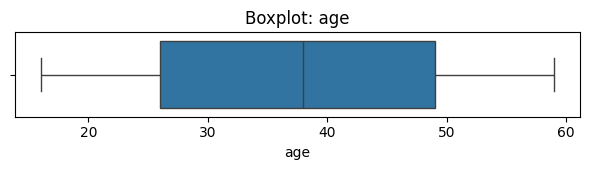

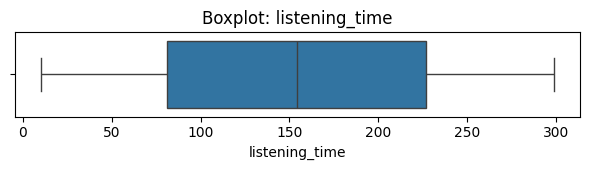

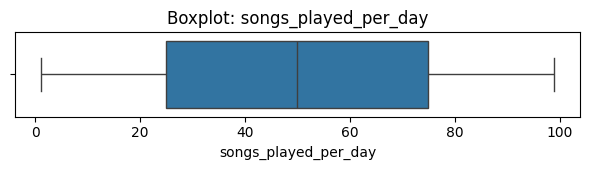

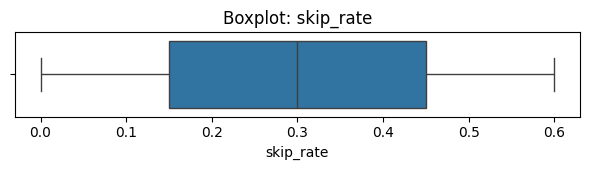

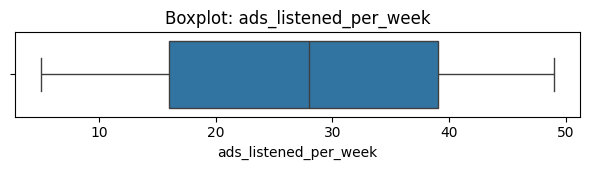

In [10]:
num_cols = num_features

for feature in num_cols:
    s = pd.to_numeric(data[feature], errors="coerce")
    if feature == "ads_listened_per_week":
        s = s[s.ne(0)]

    plt.figure(figsize=(6, 1.8))
    sns.boxplot(x=s, orient="h", whis=1.5, showfliers=True)
    plt.title(f"Boxplot: {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

**2. Menggunakan IQR**

In [11]:
def _series_for(feature):
    s = pd.to_numeric(data[feature], errors="coerce")
    if feature == "ads_listened_per_week":
        s = s[s.ne(0)]
    return s.dropna()

In [12]:
WHIS = 1.5
rows = []
for feature in num_cols:
    s = _series_for(feature)
    if s.empty:
        rows.append({"feature": feature, "lower": np.nan, "upper": np.nan,
                     "n_left":0, "n_right":0, "n_outliers":0, "n":0, "pct_outliers":0.0})
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - WHIS*iqr, q3 + WHIS*iqr
    left  = (s < lo)
    right = (s > hi)
    n_left, n_right = int(left.sum()), int(right.sum())
    n = int(s.size)
    rows.append({
        "feature": feature, "lower": lo, "upper": hi,
        "n_left": n_left, "n_right": n_right,
        "n_outliers": n_left + n_right, "n": n,
        "pct_outliers": 100.0 * (n_left + n_right) / n
    })
summary_iqr = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)
display(summary_iqr)

,feature,lower,upper,n_left,n_right,n_outliers,n,pct_outliers
0,age,-8.5,83.5,0,0,0,8000,0.0
1,listening_time,-138.0,446.0,0,0,0,8000,0.0
2,songs_played_per_day,-50.0,150.0,0,0,0,8000,0.0
3,skip_rate,-0.3,0.9,0,0,0,8000,0.0
4,ads_listened_per_week,-18.5,73.5,0,0,0,2018,0.0


**3. Menggunakan Z-Score**

In [13]:
ZSCORE_T = 3.0
rows = []
for feature in num_cols:
    s = _series_for(feature)
    if s.empty:
        rows.append({"feature": feature, "mu": np.nan, "sd": np.nan,
                     "n_outliers":0, "n":0, "pct_outliers":0.0})
        continue
    mu, sd = s.mean(), s.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        n = int(s.size)
        rows.append({"feature": feature, "mu": mu, "sd": sd,
                     "n_outliers":0, "n": n, "pct_outliers":0.0})
        continue
    z = (s - mu) / sd
    mask = z.abs() > ZSCORE_T
    n = int(s.size)
    rows.append({"feature": feature, "mu": mu, "sd": sd,
                 "n_outliers": int(mask.sum()), "n": n,
                 "pct_outliers": 100.0 * mask.mean()})
summary_z = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)
display(summary_z)

,feature,mu,sd,n_outliers,n,pct_outliers
0,age,37.662125,12.740359,0,8000,0.0
1,listening_time,154.068250,84.015596,0,8000,0.0
2,songs_played_per_day,50.127250,28.449762,0,8000,0.0
3,skip_rate,0.300127,0.173594,0,8000,0.0
4,ads_listened_per_week,27.527750,12.982368,0,2018,0.0


**4. Menggunakan MAD**

In [14]:
MAD_K = 3.5
rows = []
for feature in num_cols:
    s = _series_for(feature)
    if s.empty:
        rows.append({"feature": feature,
                     "median": np.nan,
                     "mad": np.nan,
                     "n_outliers":0,
                     "n":0,
                     "pct_outliers":0.0})
        continue

    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0 or np.isnan(mad):
        n = int(s.size)
        rows.append({"feature": feature,
                     "median": med,
                     "mad": mad,
                     "n_outliers":0,
                     "n": n,
                     "pct_outliers":0.0})
        continue

    mz = 0.6745 * (s - med) / mad
    mask = mz.abs() > MAD_K
    n = int(s.size)
    rows.append({"feature": feature, "median": med, "mad": mad,
                 "n_outliers": int(mask.sum()), "n": n,
                 "pct_outliers": 100.0 * mask.mean()})
summary_mad = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)
display(summary_mad)

,feature,median,mad,n_outliers,n,pct_outliers
0,age,38.0,11.00,0,8000,0.0
1,listening_time,154.0,73.00,0,8000,0.0
2,songs_played_per_day,50.0,25.00,0,8000,0.0
3,skip_rate,0.3,0.15,0,8000,0.0
4,ads_listened_per_week,28.0,11.00,0,2018,0.0


Dari keempat teknik tersebut, hasilnya sama yaitu data tersebut tidak terdeteksi outliernya sehingga data kita sudah bisa lanjut ke tahap selanjutnya. Dan apabila terdeteksi outlier, kita dapat menanganinya dengan beberapa cara seperti menghapus outlier, mengubah outlier menjadi nilai yang paling pingggir (batas atas dan bawah), dan lain lain.

### Visualisasi Dataset

Selanjutnya yaitu kita melakukan beberapa visualisasi data ke beberapa fitur di dataset untuk mempelajari seperti distribusi data, korelasi, dan banyak data kategorikal.

**1. Distribusi pada fitur `songs_played_per_day`**

,songs_played_per_day
0,23
1,62
2,38
3,2
4,57
...,...
7995,36
7996,64
7997,62
7998,94


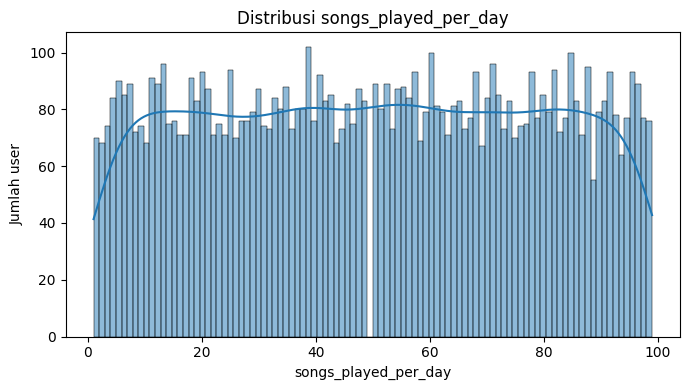

In [15]:
s = pd.to_numeric(data["songs_played_per_day"], errors="coerce").dropna()
display(s)

plt.figure(figsize=(7,4))
sns.histplot(s, bins=100, kde=True)
plt.title("Distribusi songs_played_per_day")
plt.xlabel("songs_played_per_day")
plt.ylabel("Jumlah user")
plt.tight_layout()
plt.show()

Pada grafik songs_played_per_day, menunjukkan sebaran yang nyaris uniform di rentang 1–99 lagu/hari: tidak ada skew berarti, puncak/bukit spesifik, atau ekor berat. Garis KDE yang sedikit turun di ujung kiri/kanan adalah boundary bias (wajar karena domain terbatas). Celah tipis di sekitar ~50 itu kemungkinan artefak binning (tepi bin jatuh pas di nilai integer tertentu), bukan “lubang” nyata pada data. Dengan bentuk seperti ini, deteksi outlier berbasis IQR/Z/MAD hampir tidak akan menandai apa pun (sudah dibuktikan tadi), dan transformasi (log, Box-Cox) tidak diperlukan, cukup standardize bila modelnya sensitif skala (KNN/SVM).

**2. Hubungan antara fitur `age` dengan `listening_time` menggunakan scatter plot**

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
age,1.000000,-0.012975,-0.006834,-0.019557,-0.011962,0.017061,0.003982
listening_time,-0.012975,1.000000,-0.010996,-0.013603,0.002279,-0.006421,-0.007624
songs_played_per_day,-0.006834,-0.010996,1.000000,-0.000590,-0.017813,0.018846,0.009314
skip_rate,-0.019557,-0.013603,-0.000590,1.000000,-0.012682,-0.002657,0.016121
ads_listened_per_week,-0.011962,0.002279,-0.017813,-0.012682,1.000000,-0.877970,-0.002279
offline_listening,0.017061,-0.006421,0.018846,-0.002657,-0.877970,1.000000,0.012754
is_churned,0.003982,-0.007624,0.009314,0.016121,-0.002279,0.012754,1.000000


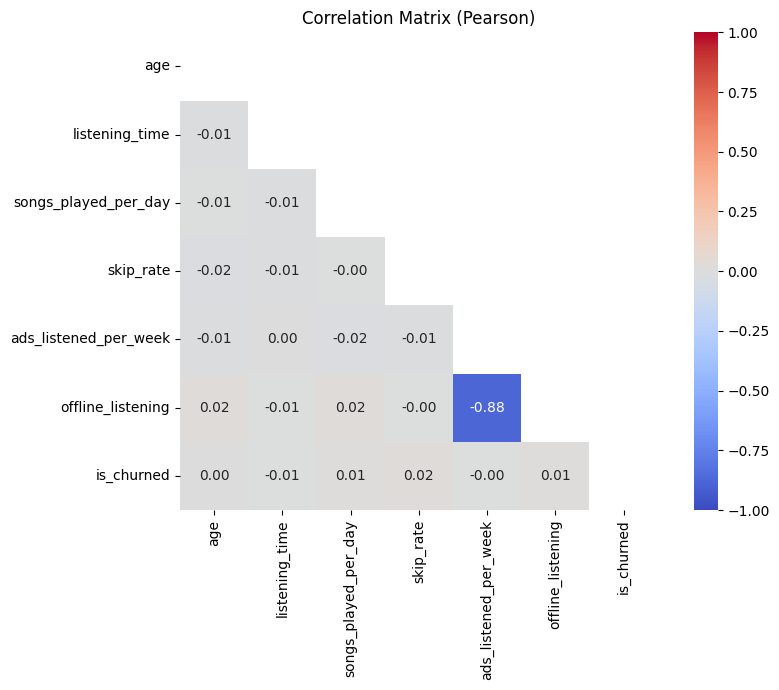

In [16]:
num_df = data.select_dtypes(include=[np.number]).copy()
id_like = [c for c in num_df.columns if c.lower() == "user_id" or c.lower().endswith("_id")]
num_df = num_df.drop(columns=id_like, errors="ignore")

corr_p = num_df.corr(method="pearson")
display(corr_p)

mask = np.triu(np.ones_like(corr_p, dtype=bool))
plt.figure(figsize=(9, 7))
sns.heatmap(corr_p, mask=mask, annot=True, fmt=".2f",
            vmin=-1, vmax=1, center=0, cmap="coolwarm", square=True)
plt.title("Correlation Matrix (Pearson)")
plt.tight_layout()
plt.show()

Kita bisa lihat bahwa nilai korelasi antar fitur memang sangat tipis kecuali untuk offline_listening dengan ads_listened_per_week, karena ketika offline_listening nya True maka tidak mungkin si user menonton satu iklan.

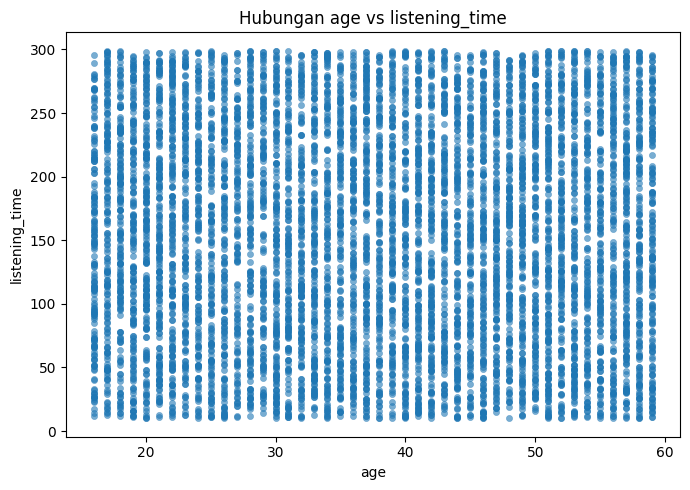

In [17]:
x = pd.to_numeric(data["age"], errors="coerce")
y = pd.to_numeric(data["listening_time"], errors="coerce")
mask = x.notna() & y.notna()

plt.figure(figsize=(7,5))
sns.scatterplot(x=x[mask], y=y[mask], s=20, alpha=0.6, edgecolor=None)
plt.title("Hubungan age vs listening_time")
plt.xlabel("age")
plt.ylabel("listening_time")
plt.tight_layout()
plt.show()

Dari visualisasi ini, kita dapat melihat bahwa hubungan antara kedua fitur ini sangat kecil karena titik titik yang ada pada scatter plot tersebut menyebar kemana mana dan tidak terbentuk pola. Saya juga sudah membuktikannya dengan menggunakan heatmap correlation dengan metode pearson dan didapat hasil seperti ini:

In [18]:
x = pd.to_numeric(data["age"], errors="coerce")
y = pd.to_numeric(data["listening_time"], errors="coerce")
m = x.notna() & y.notna()

pearson  = x[m].corr(y[m], method="pearson")
spearman = x[m].corr(y[m], method="spearman")
print({"pearson": pearson, "spearman": spearman})

{'pearson': np.float64(-0.012975472135472572), 'spearman': np.float64(-0.012675909615755793)}


**3. Cek jumlah user berdasarkan subscription type**

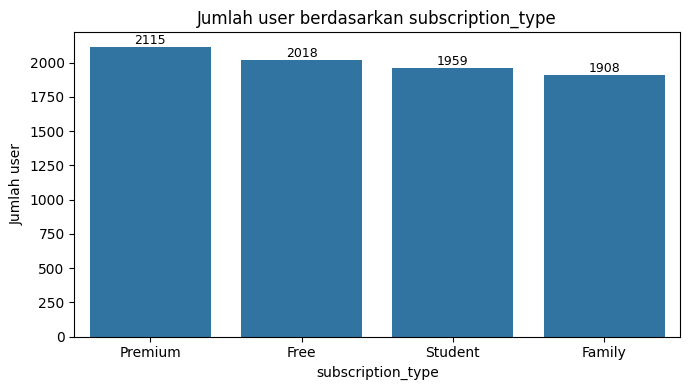

In [19]:
cats = data["subscription_type"].astype("string").fillna("Missing")
counts = cats.value_counts().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Jumlah user berdasarkan subscription_type")
plt.xlabel("subscription_type")
plt.ylabel("Jumlah user")
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

Pada Bar chart ini nunjukin distribusi kategori subscription_type yang sangat seimbang: Premium 2115 (26.4%), Free 2018 (25.2%), Student 1959 (24.5%), Family 1908 (23.9%) dari total 8.000 user. Selisih terbesar antar-kategori cuma 2.5 poin persentase, jadi tidak ada class imbalance yang mana berarti sangat bagus untuk analisis komparatif dan model klasifikasi (bisa pakai stratified split pakai kolom ini). Secara domain, ini juga konsisten dengan temuan korelasi: kategori yang identik dengan premium kemungkinan berkaitan dengan ads_listened_per_week = 0 dan offline_listening > 0.